# Proyecto de Machine Learning: Bank Marketing
## Baseline Inicial: Carga, Auditoría y Exploración de Datos

**Objetivo del Negocio**: Nos enfrentamos a un problema de clasificación binaria. El objetivo principal es predecir si un cliente aceptará o no un depósito a término fijo (variable objetivo `y`). 

**Acerca de este Notebook**: 
Este documento sirve como un **baseline robusto y reproducible** para la ingesta de datos, la revisión analítica (EDA) y la verificación de calidad de los datos. Está estructurado de forma secuencial, inspirado en metodologías probadas (como `ml_machinelearninglandscape`).

> ⚠️ **Aviso Jeison**: 
> LA idea es que vos ejecutes este flujo, que podas añadir nuevas exploraciones si lo consideras necesario, interpretar todos los resultados y asentar tus hallazgos. Al final de este documento, se espera que pases directamente a construir el baseline de preprocesamiento (split, feature engineering) pero sin tocar aún modelos de Machine Learning.

---
## 1. Setup Reproducible
Configuración inicial del entorno. Asegurando que los gráficos, las semillas y las configuraciones de pandas sean constantes a lo largo del análisis.

In [14]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

# Configuración Visual
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Opciones de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Semilla de reproducibilidad
SEED = 42
np.random.seed(SEED)

print("✅ Entorno configurado de manera reproducible.")

✅ Entorno configurado de manera reproducible.


---
## 2. Helper Functions
Funciones que nos permiten auditar el dataset de forma rápida, visualizar y no repetir código.

In [15]:
def print_section(title: str, width: int = 88) -> None:
    """Imprime un separador de sección visual."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)

def summarize_missingness(df):
    """Muestra conteo y porcentaje de nulos nativos."""
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0]
    missing_pct = (missing_data / len(df)) * 100
    
    if missing_pct.empty:
        print("✅ No hay valores nulos detectables nativamente ('NaN') en el DataFrame.")
    else:
        missing_df = pd.DataFrame({'Missing_Values': missing_data, 'Percentage': missing_pct}).sort_values(by='Percentage', ascending=False)
        display(missing_df)
        
def plot_target_distribution(df, target_col):
    """Grafica la distribución visual de la variable objetivo."""
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col, palette='viridis')
    plt.title("Distribución de la Variable Objetivo")
    plt.show()
    
    counts = df[target_col].value_counts(normalize=True) * 100
    print(f"\nPorcentaje por clase:\n{counts}")

def plot_correlation_heatmap(df):
    """Matriz de correlación rápida para variables numéricas."""
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    corr = numeric_df.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=.5)
    plt.title("Matriz de Correlación de Variables Numéricas")
    plt.show()

---
## 3. Carga del Dataset
Importamos el dataset desde [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing) usando la biblioteca `ucimlrepo`.

**Nota metodológica sobre la estructura UCI**: Este repositorio entrega los datos separados en dos bloques clave desde el origen:
- **`features` (X)**: Las variables independientes que el modelo usará para aprender (edad, trabajo, balance, etc).
- **`targets` (y)**: La variable objetivo que queremos predecir (en este caso, `y`: si el cliente aceptó o no el depósito).

Nosotros sabemos desde el inicio cuál es nuestro `target`. Sin embargo, aquí las cargaremos y formaremos un **único DataFrame temporal (`df`)** exclusivamente para aprovechar la etapa visual y auditar cómo interaccionan las características contra la variable objetivo. Más adelante se volverán a tratar por separado para evitar el Data Leakage.

In [16]:
from ucimlrepo import fetch_ucirepo

print("Descargando el dataset 'Bank Marketing' (ID 222)...")
try:
    bank_marketing = fetch_ucirepo(id=222)
    
    X = bank_marketing.data.features
    y = bank_marketing.data.targets
    
    # DataFrame consolidado únicamente para el EDA
    df = pd.concat([X, y], axis=1)
    
    print(f"✅ ¡Dataset cargado! Dimensión: {df.shape[0]:,} filas y {df.shape[1]} columnas.")
except Exception as e:
    print(f"❌ Ocurrió un error al cargar el dataset: {e}")

Descargando el dataset 'Bank Marketing' (ID 222)...
✅ ¡Dataset cargado! Dimensión: 45,211 filas y 17 columnas.


---
## 4. Auditoría Temprana y Calidad de Datos
Revisaremos tipos de datos, estadísticas básicas, valores nulos, cardinalidades inusuales y registros duplicados.

In [17]:
print_section("VISTA RÁPIDA DE LOS DATOS")
display(df.head())


                               VISTA RÁPIDA DE LOS DATOS                                


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [18]:
print_section("INFORMACIÓN DEL ESQUEMA")
df.info()


                                INFORMACIÓN DEL ESQUEMA                                 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), obje

### 4.1. Descripción Numérica Rápida
Observaremos medias, medianas, deciles/cuartiles y valores atípicos evidentes analizando los mínimos y máximos.

In [19]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,"45,211.000",40.936,10.619,18.000,33.000,39.000,48.000,95.000
balance,"45,211.000","1,362.272","3,044.766","-8,019.000",72.000,448.000,"1,428.000","102,127.000"
day_of_week,"45,211.000",15.806,8.322,1.000,8.000,16.000,21.000,31.000
duration,"45,211.000",258.163,257.528,0.000,103.000,180.000,319.000,"4,918.000"
campaign,"45,211.000",2.764,3.098,1.000,1.000,2.000,3.000,63.000
pdays,"45,211.000",40.198,100.129,-1.000,-1.000,-1.000,-1.000,871.000
previous,"45,211.000",0.580,2.303,0.000,0.000,0.000,0.000,275.000


### 4.2. Cardinalidad y Duplicados
Revisemos si hay variables de alta cardinalidad o registros exactamente duplicados (común en encuestas sin ID único).

In [20]:
print_section("CARDINALIDAD POR VARIABLE")
cardinality = df.nunique().sort_values()
display(cardinality)

print_section("DUPLICADOS ESTRUCTURALES")
duplicados = df.duplicated().sum()
pct_duplicados = (duplicados / len(df)) * 100
print(f"El dataset contiene {duplicados:,} filas duplicadas ({pct_duplicados:.2f}%)")


                               CARDINALIDAD POR VARIABLE                                


housing           2
loan              2
default           2
contact           2
y                 2
marital           3
poutcome          3
education         3
job              11
month            12
day_of_week      31
previous         41
campaign         48
age              77
pdays           559
duration       1573
balance        7168
dtype: int64


                                DUPLICADOS ESTRUCTURALES                                
El dataset contiene 0 filas duplicadas (0.00%)


### 4.3. Valores Faltantes (Explícitos e Implícitos)
Algunos datasets suele guardar los faltantes como la categoría `"unknown"`, además de los clásicos `NaN`.

In [21]:
# Revisión de Nulos Nativos
print_section("NULOS NATIVOS DE PANDAS")
summarize_missingness(df)


                                NULOS NATIVOS DE PANDAS                                 


,Missing_Values,Percentage
poutcome,36959,81.748
contact,13020,28.798
education,1857,4.107
job,288,0.637


In [22]:
# Revisión de Faltantes Implícitos ('unknown')
print_section("VALORES 'UNKNOWN' DETECTADOS")
for col in df.select_dtypes(include=['object']):
    unknowns = (df[col] == 'unknown').sum()
    if unknowns > 0:
        print(f"➔ La columna '{col}' tiene {unknowns:,} valores 'unknown' ({unknowns/len(df)*100:.2f}%)")


                              VALORES 'UNKNOWN' DETECTADOS                              


### Conclusiones sobre Calidad de Datos
**[ANALISTA - PARA QUE ACA PONGAS UN ANALISIS]**: 
*Anota aquí:*
*   *¿Qué te sugieren el Min y Max del `balance` o los cuartiles de `pdays`?*
*   *¿De qué forma deben tratarse las filas duplicadas?*
*   *¿Qué medidas tomarás respecto a los `unknown`?*


---
## 5. EDA: Análisis Exploratorio de Datos
Veamos la relación gráfica de los elementos de negocio y las correlaciones para empezar a plantear el modelo mental previo a las transformaciones.

### 5.1. Distribución de la Clase Objetivo
Comprobemos qué tan desbalanceado está el target.

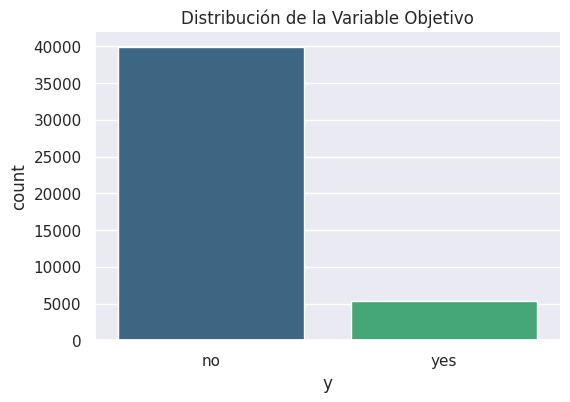


Porcentaje por clase:
y
no    88.302
yes   11.698
Name: proportion, dtype: float64


In [23]:
plot_target_distribution(df, "y")

### 5.2. Distribuciones Numéricas y Varianzas
Distribuciones generales y sesgos de variables cuantitativas.

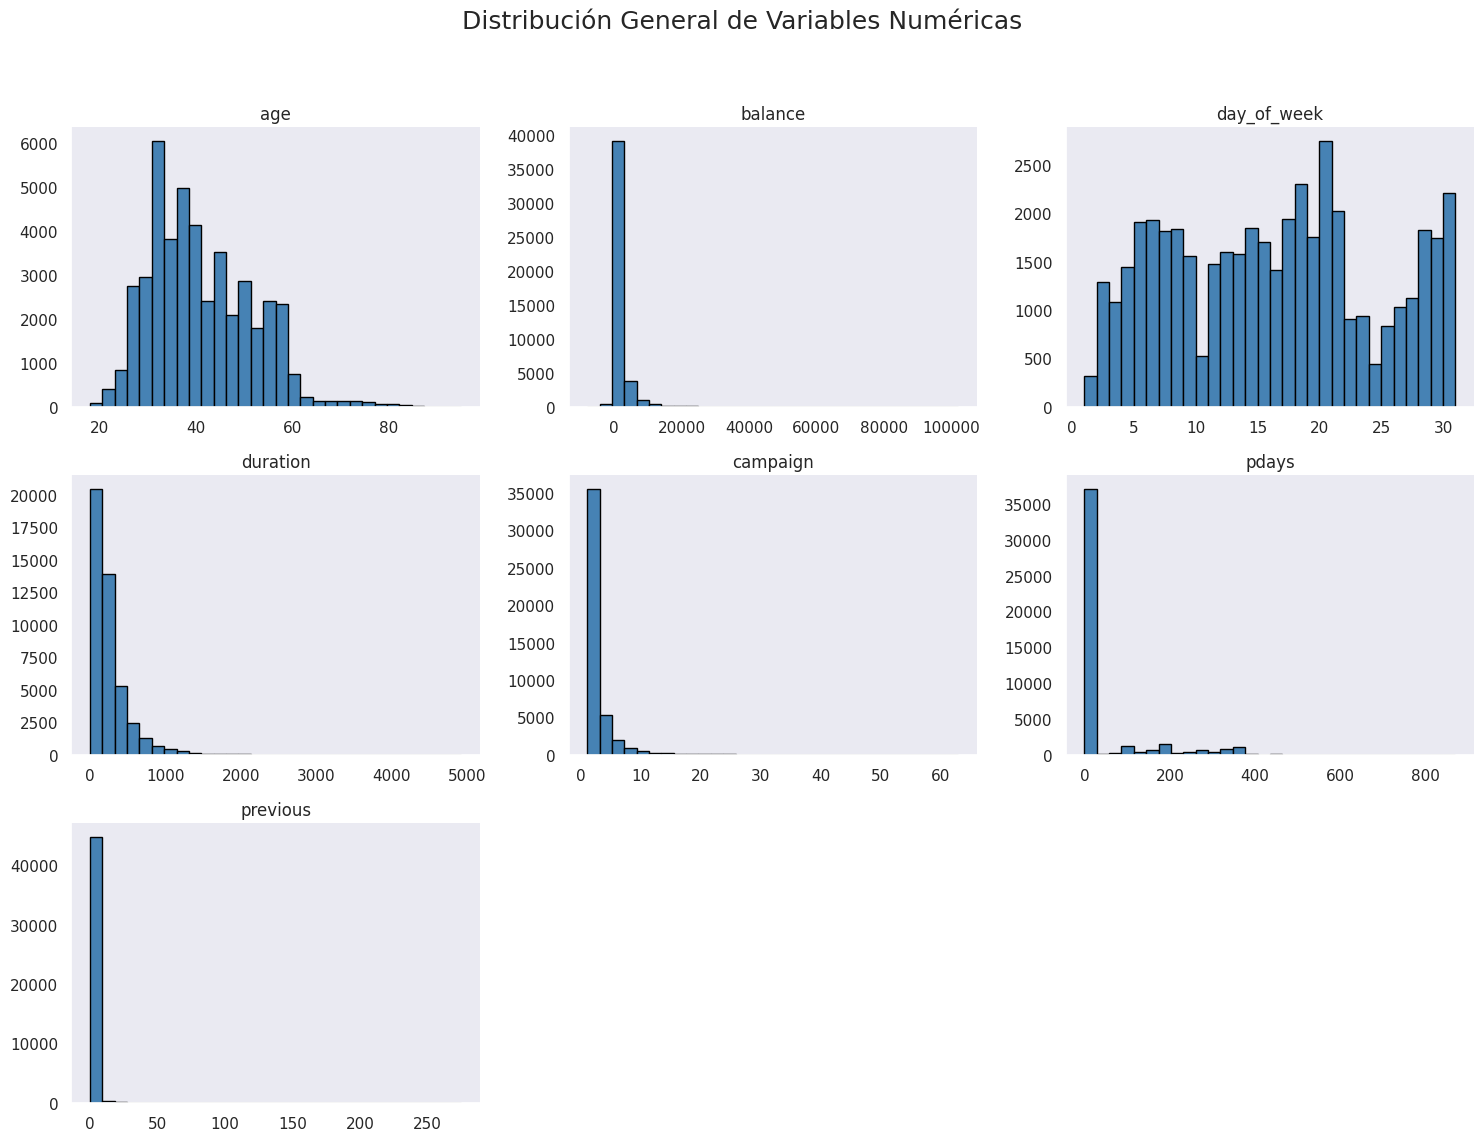

In [24]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(bins=30, figsize=(15, 12), edgecolor='black', grid=False, color='steelblue')
plt.suptitle('Distribución General de Variables Numéricas', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 5.3. Interacción Bivariada y Leakage
Contraste numérico vs aceptación.

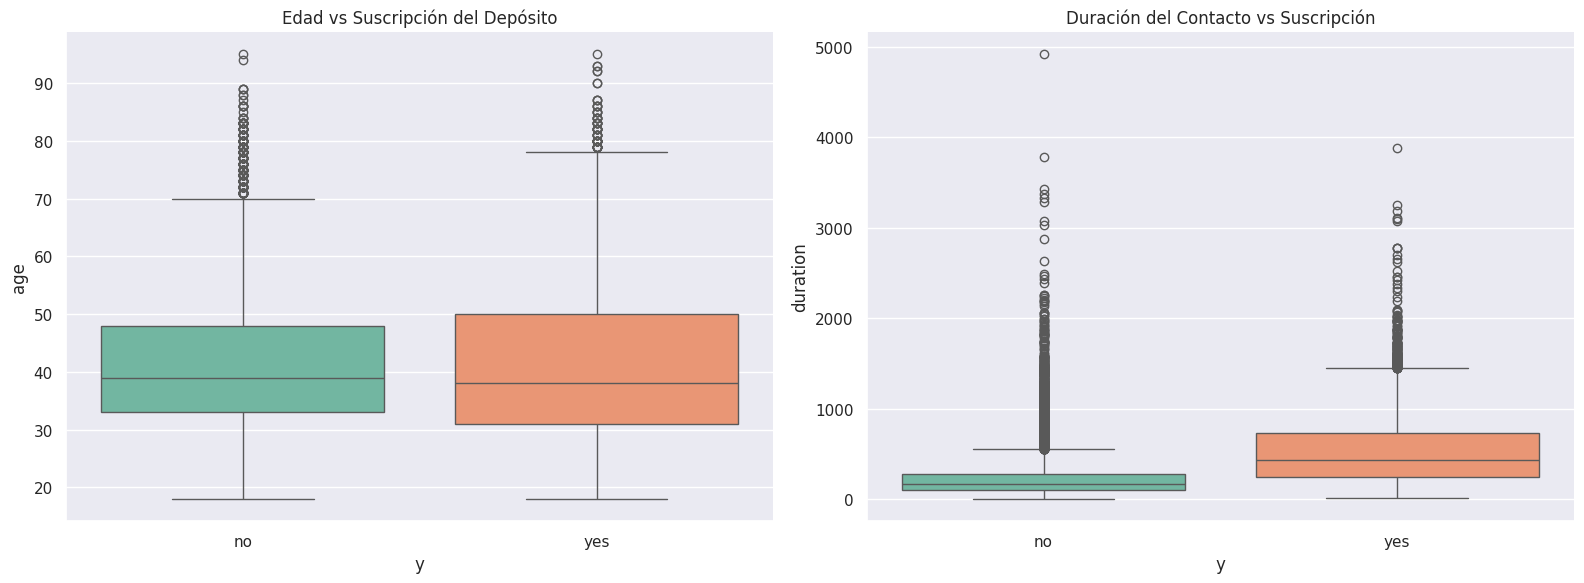

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='y', y='age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Edad vs Suscripción del Depósito')

sns.boxplot(x='y', y='duration', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Duración del Contacto vs Suscripción')

plt.tight_layout()
plt.show()

> ⚠️ **Peligro Analítico: La variable `duration` (Data Leakage)**
> La duración de la llamada (`duration`) es el tiempo que toma el asesor hablando con el posible cliente. Esta métrica solo se conoce *después* de que ocurrió la llamada, mismo instante en que descubrimos si aceptó (`y='yes'`). No podemos usar el futuro para predecir. **El atributo `duration` DEBE excluirse del pipeline final** de modelado pre-llamada, de lo contrario reportará resultados irreales.

### 5.4. Matriz de Correlación de Numéricas
En búsqueda de multicolinealidad estructural.

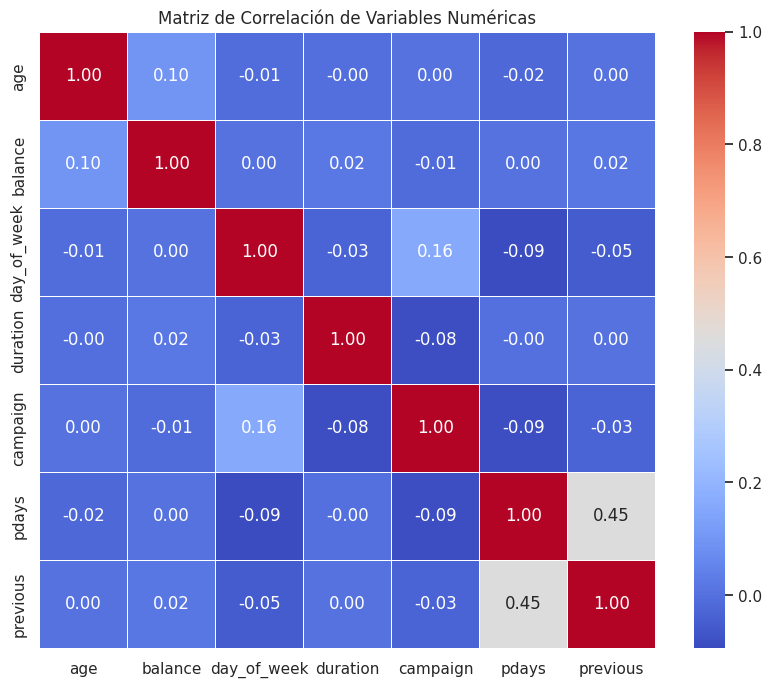

In [26]:
plot_correlation_heatmap(df)

### 5.5. Impactos Demográficos (Variables Categóricas vs Target)

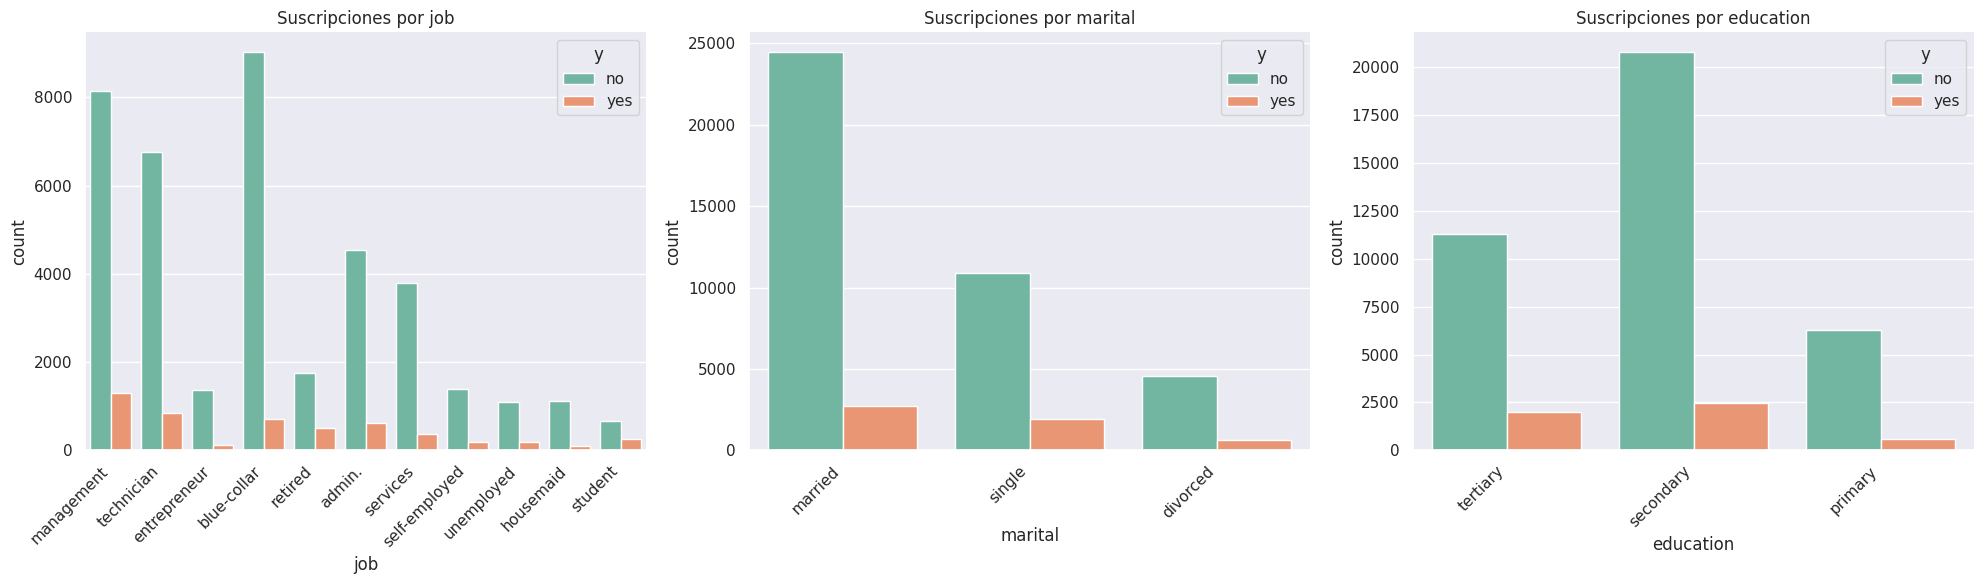

In [27]:
categorical_cols = ['job', 'marital', 'education']

plt.figure(figsize=(20, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=col, hue='y', data=df, palette='Set2')
    plt.xticks(rotation=45, ha="right")
    plt.title(f'Suscripciones por {col}')

plt.tight_layout()
plt.show()

### Conclusiones del EDA
**[ANALISTA - ESPACIO PARA EXPRESAR HALLAZGOS]**: 
*   *¿Multicolinealidad detectada en el heatmap (por ej. `pdays` vs `previous`)?*
*   *¿Algún grupo demográfico en `job` resalta fuertemente?*


---
## 6. Siguientes Pasos (Próximo Bloque)

   Parce, hasta aquí ya hemos auditado y explorado el comportamiento del dataset. Igual si crees que falto algo, lo podes añadir para complementar el analisis. Basándote en todo lo anterior, documenta a continuación qué se implementará en el bloque de preprocesamiento estructurado.

La labor ahora es armar un flujo estable para la limpieza.

**[ANALISTA - INSTRUCCIONES PARA FEATURE ENGINEERING Y PREPROCESAMIENTO]**:
Para el siguiente Jupyter Notebook (o script de pipeline), deberás definir:

1. **Partición de los Datos**: Definir estrategia para el `train_test_split` (recuerda usar partición estratificada (`stratify=y`) dado el fuerte desbalance de clase).
2. **Transformación Numérica**: 
   - Manejo de Sesgo / Outliers (ej. Log transformencias en el `balance`).
   - Técnica de Escalamiento (`StandardScaler`, `MinMaxScaler`).
3. **Manejo de Faltantes e Imputación**: Cómo atacarás los `unknowns` y NaNs.
4. **Encoding Categorías**: 
   - Elementos binarios.
   - One-Hot Encoding para Cardinalidad baja (`marital`, `housing`, etc.).
   - Alternativas a OHE para alta Cardinalidad (`job`, `month`).
5. **Mitigación Crítica**: Depuración sistemática de la columna `duration`.